# GNoME Structural Reproduction — Analysis Notebook

Master notebook for all post-processing and visualisation.
Each section calls the corresponding script in `analysis/` which:
- saves PNG plots to `results/`
- displays plots inline here
- prints a summary table to the console

---
**Workflow overview**

| Stage | Script | What it analyses |
|---|---|---|
| 1 — Baseline | `analysis/stage1_baseline/01_learning_curve.py` | Training convergence, epoch projections |
| 1 — Baseline | `analysis/stage1_baseline/02_wbm_eval.py` | WBM MAE, F1, confusion matrix |
| 1 — Stage A  | `analysis/stage1_stageA/01_learning_curve.py` | Stage A vs baseline convergence |
| 1 — Stage A  | `analysis/stage1_stageA/02_wbm_eval.py` | Stage A WBM metrics |
| 1 — Ensemble | `analysis/stage1_ensemble/01_ensemble_eval.py` | Ensemble WBM metrics |


In [1]:
import sys
from pathlib import Path

# Repo root: notebook lives in notebooks/, so repo root is one level up.
REPO_ROOT = Path().resolve().parent

# Add analysis directories to path so scripts can be imported directly.
for subdir in [
    REPO_ROOT / 'analysis' / 'stage1_baseline',
    REPO_ROOT / 'analysis' / 'stage1_stageA',
    REPO_ROOT / 'analysis' / 'stage1_ensemble',
]:
    if subdir.exists() and str(subdir) not in sys.path:
        sys.path.insert(0, str(subdir))

print(f'Repo root : {REPO_ROOT}')
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

Repo root : E:\Projects\gnome-repro-structural


---
## Stage 1 — Baseline
### 1.1 Learning Curve

Source: `runs/default/history.json`  
Outputs saved to: `results/stage1_baseline/`

Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\01_learning_curve_mae.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\01_learning_curve_loss.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\01_learning_curve_zoom.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\01_summary_table.csv

  Stage 1 Baseline — Learning Curve Summary
  Best epoch         : 199  (24.42 meV/atom)
  Final epoch MAE    : 24.42 meV/atom
  Convergence epoch  : 183  (within 2% of best)
  Last-50 slope      : -0.0579 meV/epoch
  Avg wall/epoch     : 43.2 s
  --- Projections (extrapolated) ---
  Epoch  300 : ~21.92 meV   (3.6 h)
  Epoch  500 : ~20.79 meV   (6.0 h)
  Epoch 1000 : ~20.66 meV  (12.0 h)



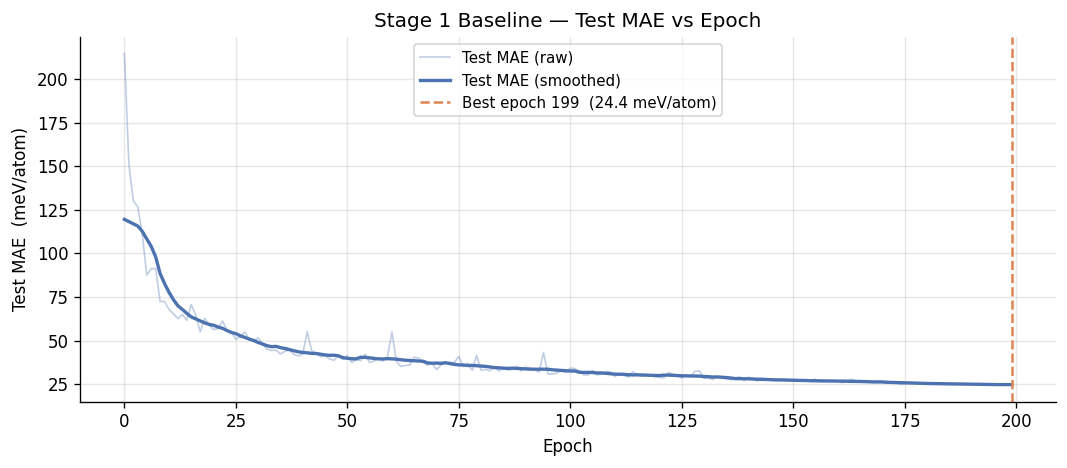

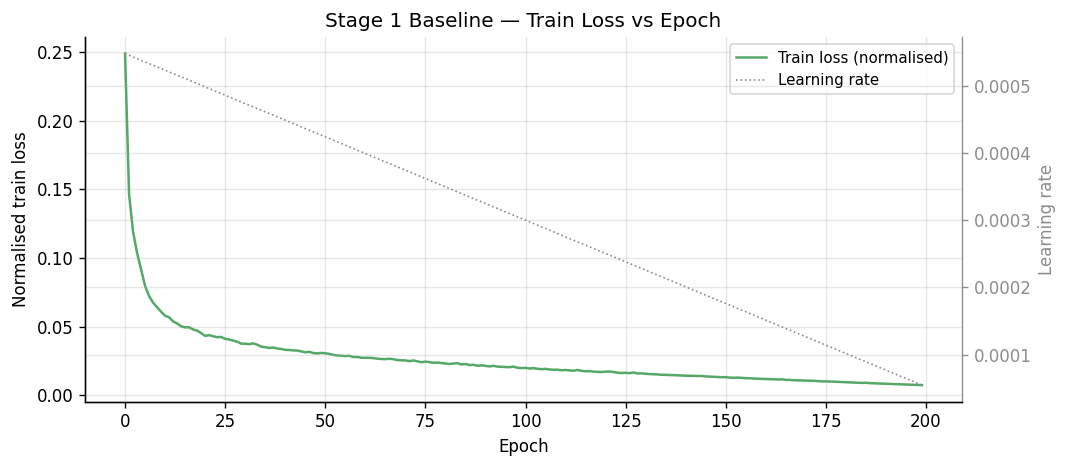

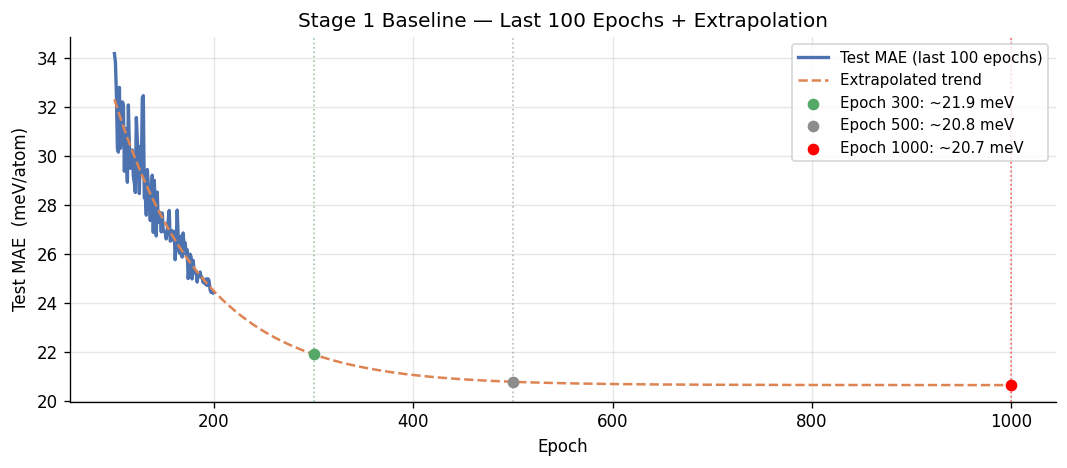

In [2]:
import importlib, learning_curve_baseline
importlib.reload(learning_curve_baseline)

summary_baseline_lc = learning_curve_baseline.run(repo_root=REPO_ROOT, show=True)

### 1.2 WBM Evaluation Summary

Source: `runs/default/metrics_wbm.json` + `runs/default/f1_wbm.json`  
Outputs saved to: `results/stage1_baseline/`

Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\02_wbm_regression_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\02_wbm_confusion_matrix.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\02_wbm_classification_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\02_wbm_summary_table.csv

  Stage 1 Baseline — WBM Evaluation Summary
  N structures  : 256,939
  MAE           : 168.76 meV/atom
  RMSE          : 253.94 meV/atom
  Bias          : 122.48 meV/atom
  F1  (raw)     : 0.3645
  Prec(raw)     : 0.2248
  Rec (raw)     : 0.9637
  F1  (corr)    : 0.3496



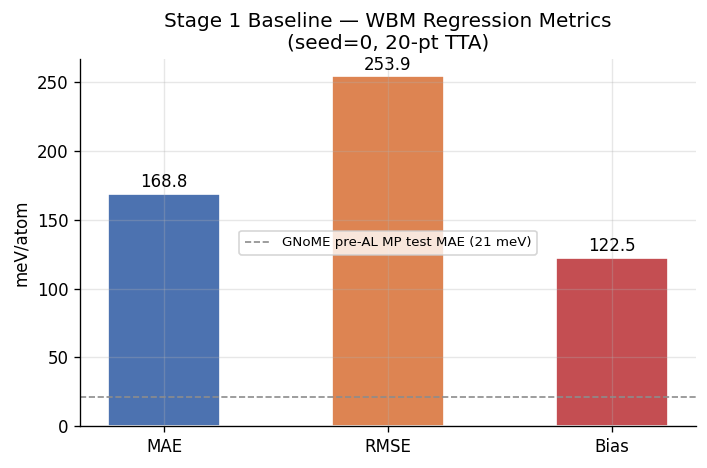

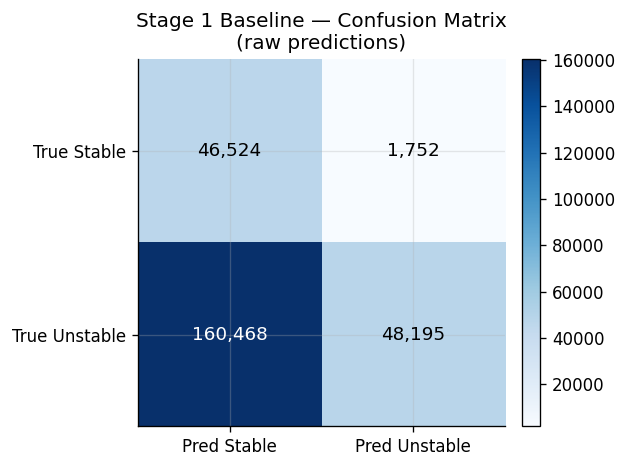

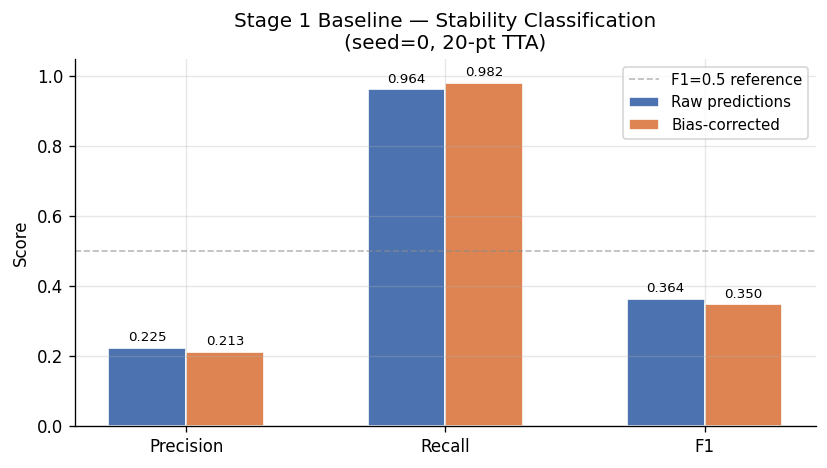

In [3]:
import importlib, wbm_eval_baseline
importlib.reload(wbm_eval_baseline)

summary_baseline_wbm = wbm_eval_baseline.run(repo_root=REPO_ROOT, show=True)

---
## Stage 1 — Stage A (longer training + EMA)
### 2.1 Learning Curve

> Run this section after Stage A training completes.

Source: `runs/stage_a/history.json`

In [ ]:
stage_a_lc_path = REPO_ROOT / 'analysis' / 'stage1_stageA' / '01_learning_curve.py'
if not stage_a_lc_path.exists():
    print('Stage A learning curve script not yet available.')
else:
    import importlib, learning_curve_stageA
    importlib.reload(learning_curve_stageA)
    summary_stageA_lc = learning_curve_stageA.run(repo_root=REPO_ROOT, show=True)

### 2.2 WBM Evaluation — Stage A vs Baseline

> Run this section after Stage A WBM eval completes.

In [ ]:
stage_a_wbm_path = REPO_ROOT / 'analysis' / 'stage1_stageA' / '02_wbm_eval.py'
if not stage_a_wbm_path.exists():
    print('Stage A WBM eval script not yet available.')
else:
    import importlib, wbm_eval_stageA
    importlib.reload(wbm_eval_stageA)
    summary_stageA_wbm = wbm_eval_stageA.run(repo_root=REPO_ROOT, show=True)

---
## Stage 1 — Ensemble (Stage C)

> Run this section after all 5 ensemble seeds complete.

Source: `runs/ensemble/`

In [ ]:
ens_path = REPO_ROOT / 'analysis' / 'stage1_ensemble' / '01_ensemble_eval.py'
if not ens_path.exists():
    print('Ensemble eval script not yet available.')
else:
    import importlib, ensemble_eval
    importlib.reload(ensemble_eval)
    summary_ensemble = ensemble_eval.run(repo_root=REPO_ROOT, show=True)

---
## Cross-Stage Comparison

Collects all available summary dicts and prints a comparison table.

In [ ]:
import pandas as pd

rows = {}
try: rows['Baseline'] = summary_baseline_wbm
except NameError: pass
try: rows['Stage A']  = summary_stageA_wbm
except NameError: pass
try: rows['Ensemble'] = summary_ensemble
except NameError: pass

if rows:
    compare_df = pd.DataFrame(rows).T
    key_cols = ['mae_meV', 'rmse_meV', 'bias_meV', 'f1_raw', 'precision_raw', 'recall_raw']
    available = [c for c in key_cols if c in compare_df.columns]
    display(compare_df[available].round(3))
else:
    print('No summary data available yet — run the sections above first.')